# # Week 05 - (2) 데이터 시각화 (Data Visualization)
## 농작물 추천 데이터셋 - 시각적 탐색

---

### 📋 학습 목표
1. Matplotlib과 Seaborn의 주요 그래프 유형을 사용할 수 있다
2. 데이터의 분포, 관계, 패턴을 시각적으로 파악할 수 있다
3. 논문 수준의 그래프를 작성할 수 있다
4. 시각화 결과를 농학적 맥락에서 해석할 수 있다

### 📊 그래프 유형 로드맵
| 그래프 | 용도 | 사용 함수 |
|--------|------|-----------|
| 히스토그램 | 단일 변수의 분포 확인 | `plt.hist()`, `sns.histplot()` |
| 박스플롯 | 그룹 간 분포 비교 | `sns.boxplot()` |
| 산점도 | 두 변수 간 관계 확인 | `plt.scatter()`, `sns.scatterplot()` |
| 히트맵 | 상관관계 행렬 시각화 | `sns.heatmap()` |
| 바이올린 플롯 | 분포의 형태와 밀도 | `sns.violinplot()` |
| 페어플롯 | 전체 변수 쌍의 관계 | `sns.pairplot()` |


---
## 1. 환경 설정 및 데이터 로딩


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 데이터 로딩
url = "https://raw.githubusercontent.com/agtechresearch/MLapplications-graduate/refs/heads/main/dataset/Crop_Recommendation_dataset.csv"
df = pd.read_csv(url)

df.head(3)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice


---
## 2. 분포 시각화 (Distribution Plots)

### 2.1 히스토그램 - 단일 변수의 분포 확인

히스토그램은 데이터가 어떤 값 범위에 몰려 있는지 보여줍니다. 생명과학 논문에서 실험 데이터의 분포를 제시할 때 자주 사용됩니다.


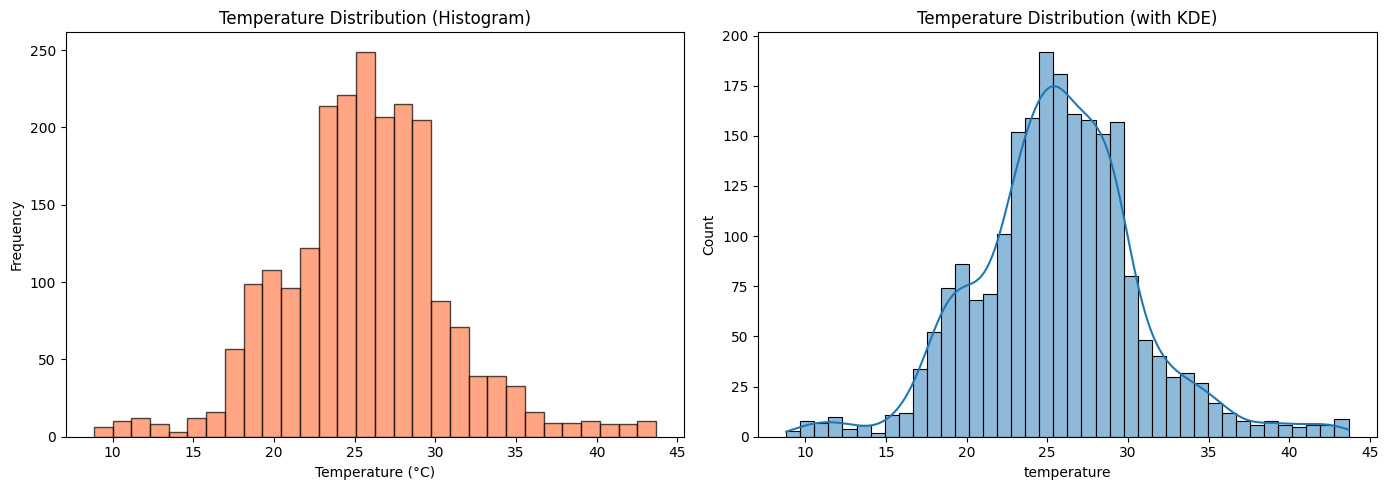

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 기본 히스토그램
axes[0].hist(df['temperature'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_title('Temperature Distribution (Histogram)')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Frequency')

# Seaborn KDE 포함 히스토그램
# Kernel Density Estimation (KDE): 확률 밀도 함수(probability density function)를 추정하여 데이터 분포를 부드럽게 나타내는 방법
sns.histplot(data=df, x='temperature', kde=True, ax=axes[1])
axes[1].set_title('Temperature Distribution (with KDE)')

plt.tight_layout()
plt.show()

### 2.2 전체 수치 변수의 분포를 한눈에

7개 수치 변수의 분포를 한 번에 그려서 각 변수의 특성을 파악합니다.


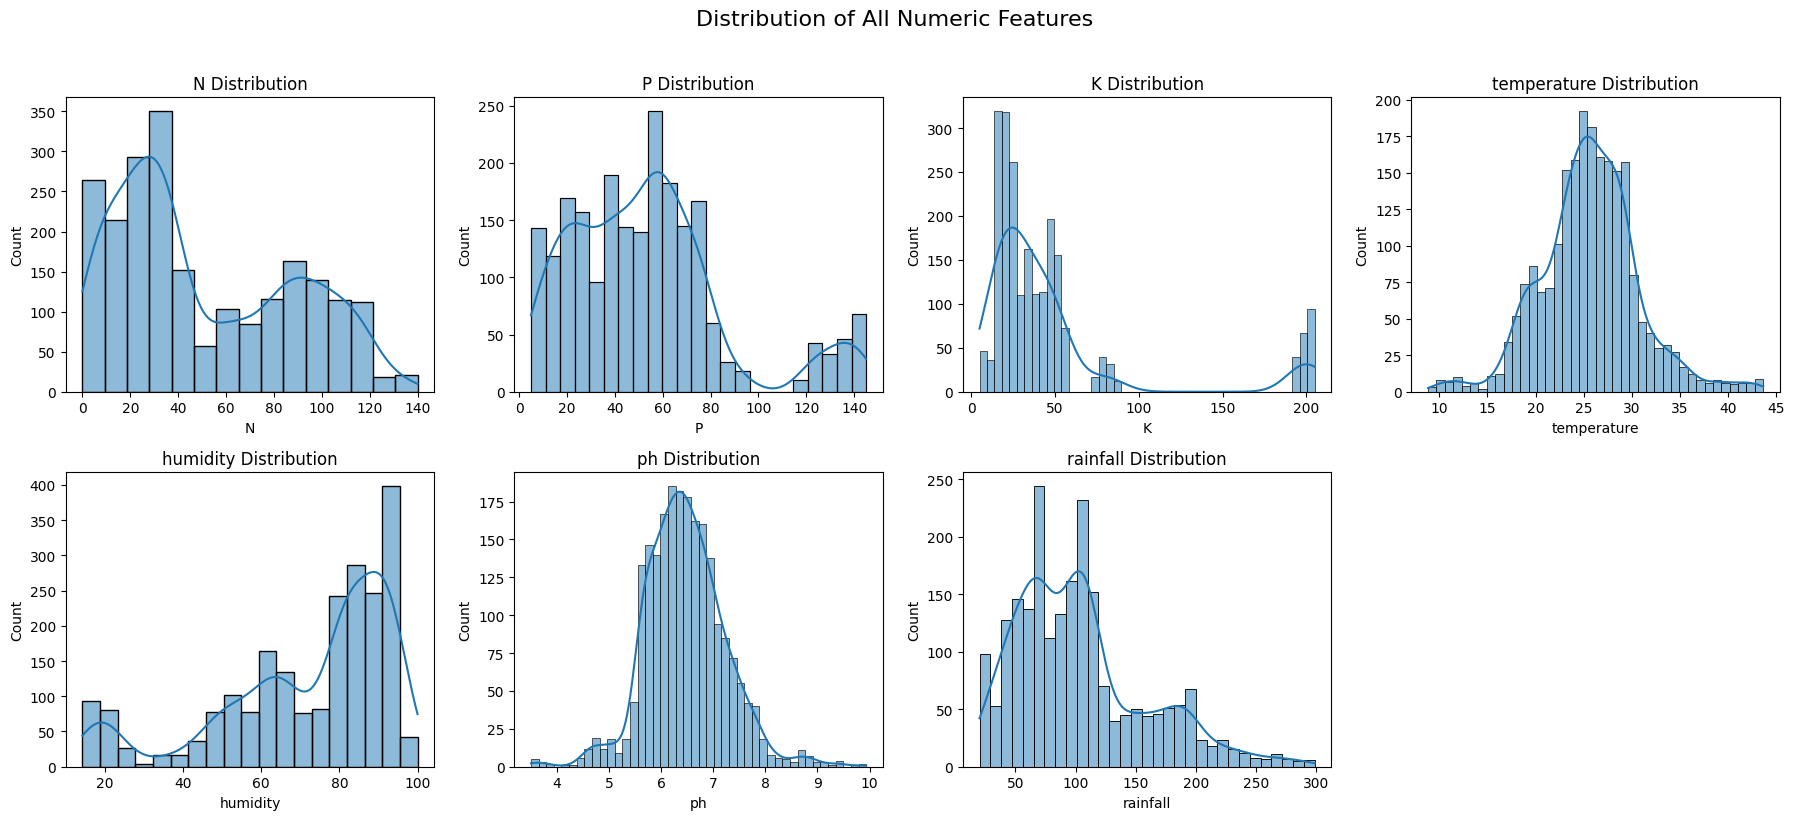

In [ ]:
# 전체 수치 변수 분포
numeric_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    # TODO: 각 변수에 대해 histplot을 그리세요
    # 힌트: sns.histplot(data=df, x=col, kde=True, ax=______)
    axes[i].set_title(f'{col} Distribution')

# 마지막 빈 subplot 제거
axes[7].set_visible(False)
plt.suptitle('Distribution of All Numeric Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

---
## 3. 박스플롯 (Boxplot) - 그룹 간 비교의 핵심 도구

> 🔬 **논문 활용 팁**: 생명과학 논문에서 처리구(treatment) 간 비교할 때 가장 많이 사용되는 그래프입니다. 중앙값, 사분위범위(IQR), 이상치를 한눈에 보여줍니다.

### 3.1 작물별 온도 비교


In [ ]:
# 일부 작물만 선택하여 보기 좋게 비교
selected = ['rice', 'wheat', 'maize', 'cotton', 'coffee', 'apple', 'grapes', 'watermelon']
df_sel = df[df['label'].isin(selected)]

plt.figure(figsize=(14, 6))

# TODO: sns.boxplot을 사용하여 작물별 온도 분포를 비교하세요
# x축: label, y축: temperature
# 힌트: sns.boxplot(data=df_sel, x='______', y='________')

plt.title('Optimal Temperature by Crop', fontsize=14)
plt.xlabel('Crop')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3.2 토양 영양소(N, P, K) 비교 - 다중 박스플롯

하나의 Figure에 여러 변수의 박스플롯을 배치하면 비교가 용이합니다.


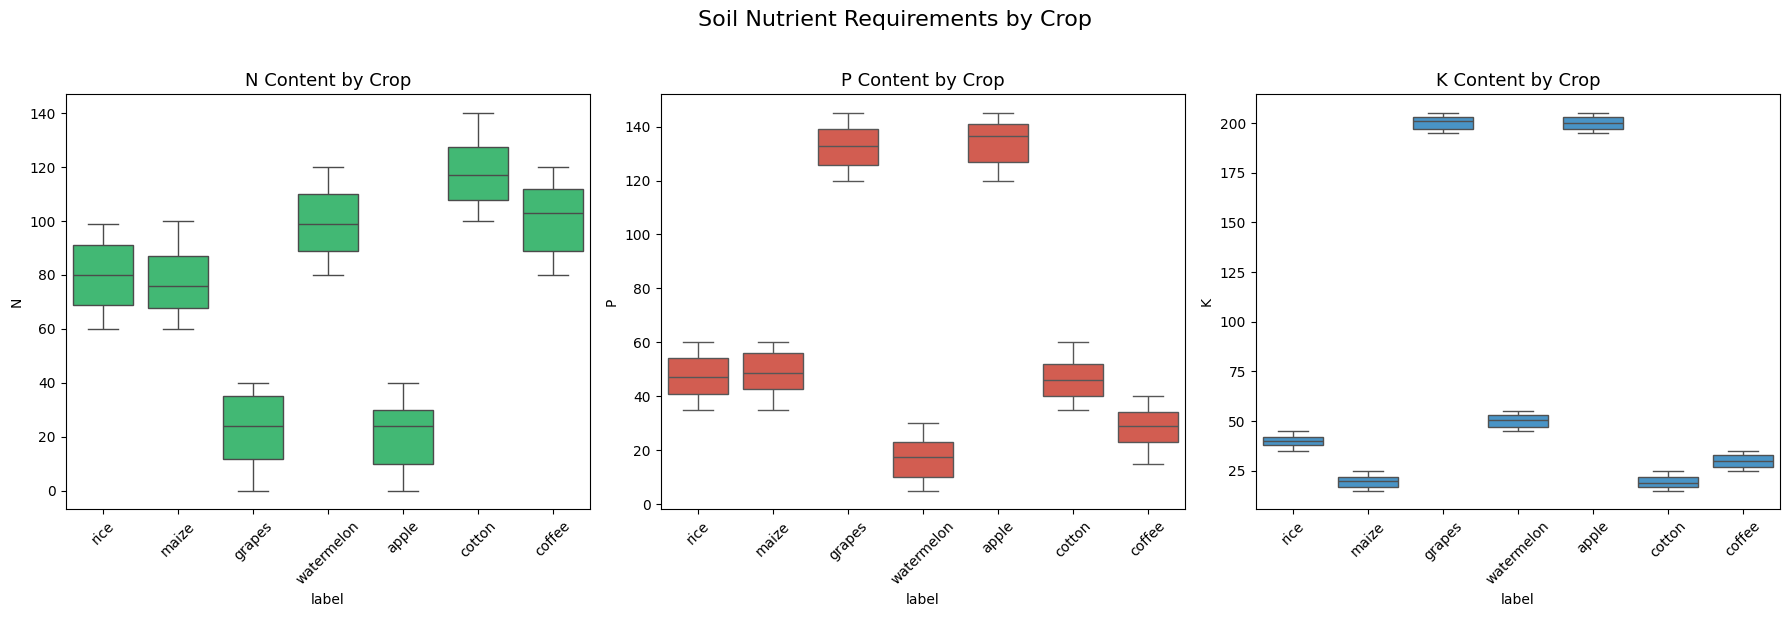

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
nutrients = ['N', 'P', 'K']
colors = ['#2ecc71', '#e74c3c', '#3498db']

for i, (nutrient, color) in enumerate(zip(nutrients, colors)):
    # TODO: 각 영양소(nutrient)에 대해 작물별 박스플롯을 그리세요
    # 힌트: sns.boxplot(data=df_sel, x='label', y=______, ax=axes[i], color=color)

    axes[i].set_title(f'{nutrient} Content by Crop', fontsize=13)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Soil Nutrient Requirements by Crop', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

---
## 4. 산점도 (Scatter Plot) - 변수 간 관계 탐색

### 4.1 온도 vs 습도 (작물별 색상 구분)


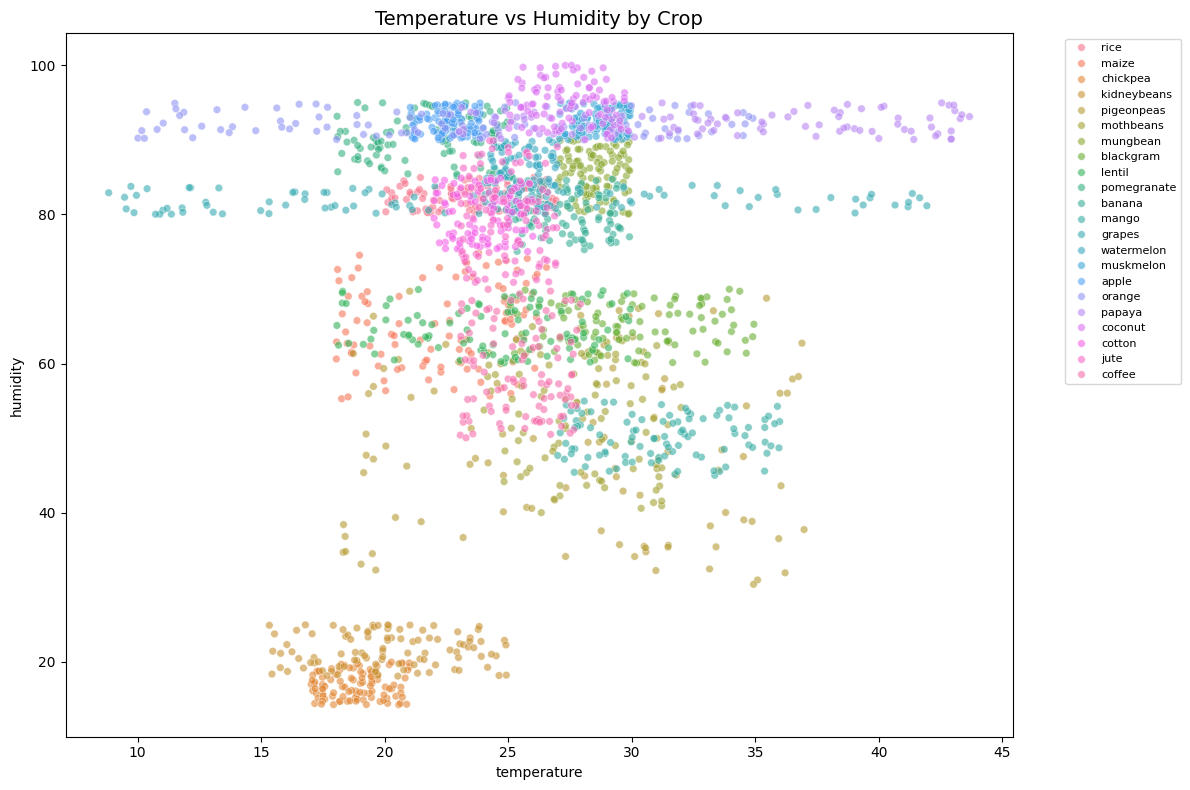

In [ ]:
plt.figure(figsize=(12, 8))

# TODO: sns.scatterplot을 사용하여 온도-습도 산점도를 그리세요
# 작물(label)별로 색상을 구분하세요
# 힌트: sns.scatterplot(data=df, x='temperature', y='humidity', hue='______', s=30)

plt.title('Temperature vs Humidity by Crop', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### 4.2 N vs K 비율 - 비료 배합 관점
질소(N)와 칼륨(K)의 관계를 통해 작물별 비료 요구 특성을 파악할 수 있습니다.


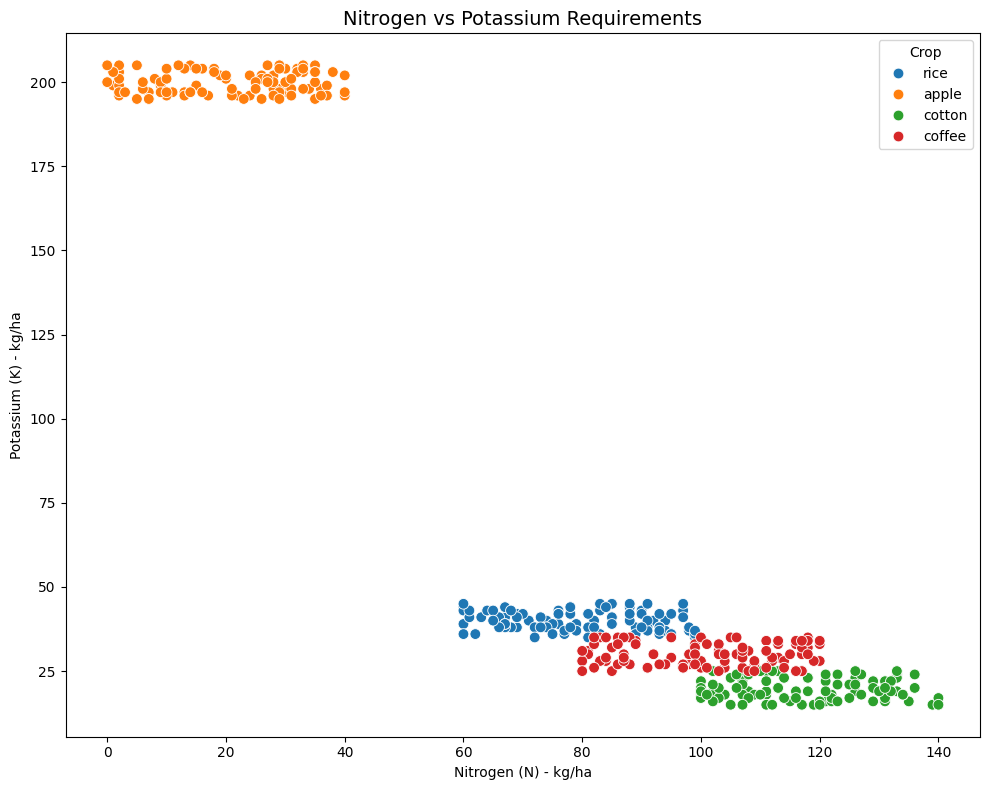

In [ ]:
plt.figure(figsize=(10, 8))

# 5가지 작물군만 선택하여 명확하게 시각화
focus_crops = ['rice', 'wheat', 'cotton', 'apple', 'coffee']
df_focus = df[df['label'].isin(focus_crops)]

# TODO: 선택된 작물에 대해 N vs K 산점도를 그리세요
# hue로 작물 구분, size로 점 크기를 동일하게 설정
# 힌트: sns.scatterplot(data=df_focus, x='N', y='K', hue='______', s=60)


plt.title('Nitrogen vs Potassium Requirements', fontsize=14)
plt.xlabel('Nitrogen (N) - kg/ha')
plt.ylabel('Potassium (K) - kg/ha')
plt.legend(title='Crop')
plt.tight_layout()
plt.show()

---
## 5. 페어플롯 (Pair Plot) - 전체 변수 관계 한눈에 보기

`pairplot`은 모든 변수 쌍의 산점도와 각 변수의 분포를 행렬 형태로 한 번에 그려줍니다. EDA의 꽃이라 할 수 있습니다.

> ⚠️ 전체 데이터(2,200개 × 22작물)를 그리면 복잡하므로, 일부 작물만 선택합니다.


In [ ]:
# 3개 작물만 선택
pair_crops = ['rice', 'apple', 'cotton']
df_pair = df[df['label'].isin(pair_crops)]

# hue='label'로 작물별 색상 구분
sns.pairplot(data=df_pair, hue='label', palette='Set1', diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20})


plt.suptitle('Pair Plot: Rice vs Apple vs Cotton', y=1.02, fontsize=16)
plt.show()

---
## 6. 히트맵 - 작물별 환경 조건 프로파일

### 작물별 평균 환경 조건 히트맵

각 작물이 선호하는 환경 조건을 한눈에 비교할 수 있는 강력한 시각화입니다.


In [ ]:
# 작물별 평균을 구하고, 스케일링 (0~1 범위)
from sklearn.preprocessing import MinMaxScaler

crop_means = df.groupby('label').mean()
scaler = MinMaxScaler()
crop_scaled = pd.DataFrame(
    scaler.fit_transform(crop_means),
    index=crop_means.index,
    columns=crop_means.columns
)

plt.figure(figsize=(10, 14))

# TODO: sns.heatmap을 사용하여 스케일링된 작물별 환경 조건을 시각화하세요
sns.heatmap(crop_scaled, annot=True, fmt='.2f', cmap='YlGn')


plt.title('Crop Environmental Profile (Normalized)', fontsize=14)
plt.xlabel('Environmental Features')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()

---
## 7. 정리

### 📝 오늘 배운 그래프 유형
| 그래프 | 핵심 용도 | 논문 활용 |
|--------|-----------|-----------|
| 히스토그램 | 변수 분포 확인 | 실험 데이터 분포 제시 |
| 박스플롯 | 그룹 간 비교 | 처리구 간 유의차 비교 |
| 산점도 | 변수 간 관계 | 상관관계 시각화 |
| 페어플롯 | 다변량 관계 탐색 | EDA 결과 제시 |
| 히트맵 | 다변량 패턴 요약 | 유전자 발현, 환경 조건 |

### 🔜 다음 주 예고: Week 07 - 머신러닝 모델링
시각화로 발견한 패턴을 기반으로, 실제로 토양·기후 데이터로 작물을 예측하는 ML 모델을 구축합니다!
(머신러닝 주요 알고리즘 적용: Decision tree, random forest 등)
